# Recurrent neural networks: watching gradients vanish through time

**Purpose.** Turn the vanishing-gradient problem from a sentence you have read into a curve you have measured. You will supervise a single timestep of a vanilla RNN, back-propagate through time, and watch how much of that learning signal survives the trip back to each earlier step.

**Prerequisites.** Feed-forward networks, backpropagation, and the softmax cross-entropy loss. The recurrence, its shapes, and the backpropagation-through-time (BPTT) equations are catalogued in the [reference](../../reference/recurrent-neural-networks/); the reasoning behind them is in the [explanation](../../explanation/recurrent-neural-networks/). This notebook *measures* what those pages derive.

**What you will be able to do by the end.**

- Read a learning signal off the `dx` gradient that BPTT returns, one step at a time.
- Show that the signal decays — or grows — geometrically with distance back through time.
- Tie that rate to a single number, the recurrent weight's spectral radius, and predict which regime (vanishing, stable, exploding) a given weight produces.
- Say precisely what gradient clipping fixes, and what it leaves untouched.

**What this notebook is not.** It does not re-implement the RNN. Every forward pass, every gradient, and the clipping rule are imported from the hub's canonical NumPy module, `dlhub.nn.sequence.rnn` — the same code the reference documents and the finite-difference tests check.

**Runtime.** A few seconds on a laptop CPU. **Seed.** `np.random.seed(1)`, set once in the setup cell, so every number below is reproducible.

### Where this fits

| Reader wants to | Go to |
| --- | --- |
| Learn it step by step | **This notebook** — you are here |
| Do it in a project | Not written for this topic — see the language-modeling-and-sampling topic |
| Look up an equation or shape | [Recurrent neural networks (reference)](../../reference/recurrent-neural-networks/) |
| Understand why it works | [Recurrent neural networks (explanation)](../../explanation/recurrent-neural-networks/) |
| Learn by running it | **This notebook** — you are here |

## 1. Orient: one cell, unrolled, and the signal that has to travel

A vanilla RNN applies one shared cell at every timestep. With activation $a$, input $x$, and prediction $\hat{y}$,

$$a^{\langle t\rangle} = \tanh\!\big(W_{aa}\,a^{\langle t-1\rangle} + W_{ax}\,x^{\langle t\rangle} + b_a\big), \qquad \hat{y}^{\langle t\rangle} = \mathrm{softmax}\!\big(W_{ya}\,a^{\langle t\rangle} + b_y\big),$$

starting from $a^{\langle 0\rangle} = \mathbf{0}$. Training unrolls this cell over the sequence and back-propagates through the whole chain — *backpropagation through time*.

That chain is what makes long-range learning hard. For the loss at a late step to teach an early input, its gradient must travel back across every step in between, and each step multiplies it by the same recurrence Jacobian. Propagating back $k$ steps multiplies $k$ copies:

$$\frac{\partial a^{\langle t\rangle}}{\partial a^{\langle t-k\rangle}} = \prod_{i=t-k+1}^{t} \operatorname{diag}\!\big(1 - (a^{\langle i\rangle})^2\big)\,W_{aa}.$$

Each $\tanh$ factor $\operatorname{diag}(1 - a^2)$ has entries in $[0, 1]$, so when the activations stay small the product is governed by $W_{aa}$ alone, and its size after $k$ steps scales roughly like $s^{k}$, where $s$ is the **spectral radius** of $W_{aa}$ (its largest eigenvalue magnitude). If $s < 1$ the signal **vanishes**; if $s > 1$ it **explodes**. That is the claim. We are going to measure it.

The plan mirrors that geometry. We supervise a **single** timestep — the last one — and read off the gradient $dx^{\langle t\rangle}$ that BPTT delivers to every step. Because only the last step carries a target, whatever gradient reaches an earlier step got there entirely by travelling back through the recurrence, which is exactly the path we care about.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from dlhub.nn.sequence.rnn import clip_gradients, rnn_backward, rnn_forward

np.random.seed(1)  # reproducibility: fixed once, here.

# A deliberately small, near-linear setup. The biases are zero and the inputs
# are tiny (scale 1e-3), so the hidden activations stay close to 0 -- where tanh
# is almost linear and 1 - a^2 is almost 1. That isolates the one effect we want
# to see, the recurrent weight, from tanh saturation, which is a separate story.
n_x, n_a, n_y, m, T_x = 3, 8, 2, 16, 15
INPUT_SCALE = 1e-3

Wax = np.random.randn(n_a, n_x)
Waa_base = np.random.randn(n_a, n_a)  # rescaled per experiment below
Wya = np.random.randn(n_y, n_a)
ba = np.zeros((n_a, 1))
by = np.zeros((n_y, 1))

x = INPUT_SCALE * np.random.randn(n_x, m, T_x)
a0 = np.zeros((n_a, m))

print(f"sequence: {T_x} steps, batch {m}, hidden size {n_a}, input dim {n_x}")

sequence: 15 steps, batch 16, hidden size 8, input dim 3


In [2]:
def with_spectral_radius(weight, target):
    """
    Rescale a square matrix so its largest eigenvalue magnitude equals ``target``.

    This only sets a knob on W_aa; it is not part of the RNN algorithm.
    """
    radius = np.max(np.abs(np.linalg.eigvals(weight)))
    return weight * (target / radius)


def gradient_reaching_each_step(params, x_seq, a0_seq):
    """
    Supervise only the final step, then measure ||dx^{<t>}|| for every t.

    The forward pass and BPTT are the canonical imports; this wrapper only builds
    a "last step only" target and reads the gradient BPTT delivers to each input
    step. Setting the target equal to the prediction at every other step makes
    those steps' output-gradient exactly zero, so the only signal flowing into an
    earlier step is the recurrence carrying the final step's gradient back.
    """
    a, y_pred, caches = rnn_forward(x_seq, params, a0_seq)
    n_y_, m_, t_x = y_pred.shape
    y = y_pred.copy()  # target == prediction  =>  zero output-gradient
    final = np.zeros((n_y_, m_))
    final[0, :] = 1.0  # one real one-hot target, at the last step only
    y[:, :, -1] = final
    grads = rnn_backward(y, caches, params)
    dx = grads["dx"]  # (n_x, m, T_x)
    per_step = np.array([np.linalg.norm(dx[:, :, t]) for t in range(t_x)])
    return per_step, grads, float(np.max(np.abs(a)))

## 2. The smallest example: a four-step sequence

Start as small as the phenomenon allows. Take the first four steps, give the last one a target, and print the size of the gradient BPTT sends back to each step. Use a recurrent weight whose spectral radius is $s = 0.7$ — comfortably below one.

In [3]:
params_vanish = {
    "Wax": Wax,
    "Waa": with_spectral_radius(Waa_base, 0.7),
    "Wya": Wya,
    "ba": ba,
    "by": by,
}

short_norms, _, short_maxa = gradient_reaching_each_step(params_vanish, x[:, :, :4], a0)

print(f"max|a| over the sequence: {short_maxa:.4f}  (near 0 => tanh is near-linear)\n")
print("step t   ||dx^<t>||   steps back from the supervised step")
for t, g in enumerate(short_norms):
    print(f"  {t}       {g:8.4f}          {3 - t}")
print(f"\nsupervised step / first step = {short_norms[-1] / short_norms[0]:.2f}x")

max|a| over the sequence: 0.0083  (near 0 => tanh is near-linear)

step t   ||dx^<t>||   steps back from the supervised step
  0         0.3805          3
  1         0.6066          2
  2         0.3992          1
  3         0.5799          0

supervised step / first step = 1.52x


Over just four steps the trend is hard to read: the norms above are roughly `[0.38, 0.61, 0.40, 0.58]` — not yet a clean slide downward — and three steps back the gradient is still about two-thirds of its size at the supervised step (the final line prints `1.52x`). Four steps is too short a lever: the geometric $s^{k}$ decay is present, but over so short a run the noise of a single random draw still dominates it. To see the decay cleanly, we need a longer sequence.

## 3. Inspect: the decay over a full sequence

Run the same measurement over all 15 steps and plot the gradient norm against *distance back through time* — zero at the supervised step, growing as we move into the past. A logarithmic vertical axis turns geometric decay into a straight line, whose slope is the decay factor per step.

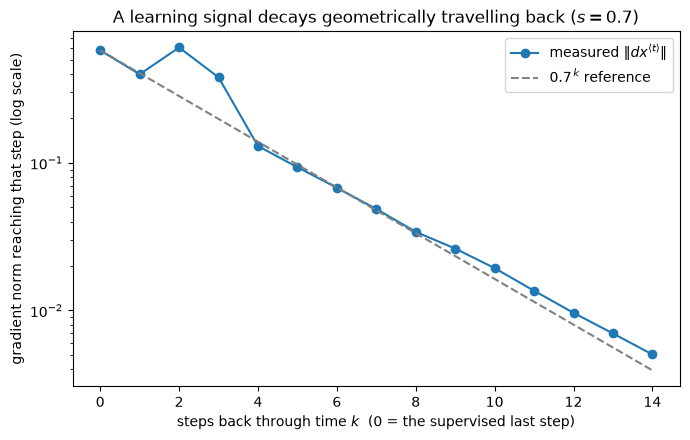

measured decay factor per step: 0.699   (W_aa spectral radius s = 0.700)
gradient at the far end is 115x smaller than at the supervised step
max|a| = 0.0083  =>  1 - a^2 ~ 1, so the recurrence Jacobian is essentially W_aa


In [4]:
norms, _, maxa = gradient_reaching_each_step(params_vanish, x, a0)
g = norms[::-1]  # index by distance back k, with k = 0 at the supervised step
k = np.arange(T_x)

# The slope of the straight line on the log axis is the per-step decay factor.
measured_factor = np.exp(np.polyfit(k, np.log(g), 1)[0])

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.semilogy(k, g, "o-", color="#1f77b4", label=r"measured $\|dx^{\langle t\rangle}\|$")
ax.semilogy(k, g[0] * 0.7**k, "--", color="grey", label=r"$0.7^{\,k}$ reference")
ax.set_xlabel(r"steps back through time $k$  (0 = the supervised last step)")
ax.set_ylabel("gradient norm reaching that step (log scale)")
ax.set_title(r"A learning signal decays geometrically travelling back ($s = 0.7$)")
ax.legend()
fig.tight_layout()
plt.show()

print(
    f"measured decay factor per step: {measured_factor:.3f}   (W_aa spectral radius s = 0.700)"
)
print(
    f"gradient at the far end is {g[0] / g[-1]:.0f}x smaller than at the supervised step"
)
print(
    f"max|a| = {maxa:.4f}  =>  1 - a^2 ~ 1, so the recurrence Jacobian is essentially W_aa"
)

**What to notice.** The points fall on a straight line on the log axis, and it sits right on the $0.7^{k}$ reference: the measured per-step decay factor matches the spectral radius of $W_{aa}$ to three digits. Fourteen steps back — the far end of the sequence — the gradient is already about $10^{2}$ times smaller. A signal that faint cannot move the weights — the network is effectively blind to what happened that far back. That is a vanishing gradient, and nothing in the code is wrong: it is the geometry of multiplying by the same matrix over and over.

## 4. Vary one thing: the recurrent weight's scale

Change exactly one number and hold everything else fixed — the inputs, the other weights, the seed. Rescale $W_{aa}$ to three spectral radii:

- $s = 0.7$ — the case above,
- $s = 1.0$ — the boundary,
- $s = 1.3$ — larger than one.

**Predict before you run the next cell.** The gradient $k$ steps back scales like $s^{k}$. Which curve falls, which stays level, and which rises — and by how much, fourteen steps back?

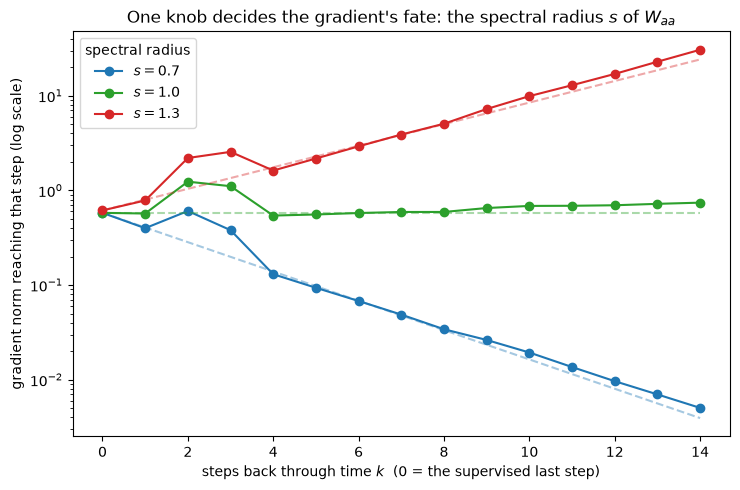

In [5]:
scenarios = {0.7: "#1f77b4", 1.0: "#2ca02c", 1.3: "#d62728"}

fig, ax = plt.subplots(figsize=(7.5, 5))
for s, color in scenarios.items():
    params_s = {
        "Wax": Wax,
        "Waa": with_spectral_radius(Waa_base, s),
        "Wya": Wya,
        "ba": ba,
        "by": by,
    }
    norms_s, _, _ = gradient_reaching_each_step(params_s, x, a0)
    g_s = norms_s[::-1]
    ax.semilogy(k, g_s, "o-", color=color, label=f"$s = {s}$")
    ax.semilogy(k, g_s[0] * s**k, "--", color=color, alpha=0.4)  # s^k reference

ax.set_xlabel(r"steps back through time $k$  (0 = the supervised last step)")
ax.set_ylabel("gradient norm reaching that step (log scale)")
ax.set_title(
    r"One knob decides the gradient's fate: the spectral radius $s$ of $W_{aa}$"
)
ax.legend(title="spectral radius")
fig.tight_layout()
plt.show()

**What to notice.** Three straight lines, one knob. With $s < 1$ the gradient collapses toward the past (**vanishing**); with $s > 1$ it grows toward the past (**exploding** — roughly $50\times$ larger fourteen steps back); at $s = 1$ it holds level, the knife-edge between them. Each solid measured line tracks its own dashed $s^{k}$ reference, because the tiny activations keep the recurrence Jacobian close to $W_{aa}$. The very same multiply-by-$W_{aa}$-every-step that lets the network carry information forward is what corrupts the gradient travelling back: below one it forgets, above one it blows up.

## 5. What this means, and what it does not

The exploding case has a standard remedy: **global-norm gradient clipping**. Stack every parameter gradient into one long vector; if that vector's norm exceeds a cap, rescale all of them by the same factor — capping the magnitude while keeping the direction (Pascanu, Mikolov & Bengio, 2013). The hub ships it as `clip_gradients`. Watch which of our three cases it actually touches, with the cap set to `5.0`.

In [ ]:
def global_norm(param_grads):
    """L2 norm of all gradients stacked into one vector -- what clipping caps."""
    return float(np.sqrt(sum(np.sum(g**2) for g in param_grads.values())))


def parameter_gradients_for(s):
    """Parameter gradients from the last-step-only setup, at spectral radius ``s``."""
    params_s = {
        "Wax": Wax,
        "Waa": with_spectral_radius(Waa_base, s),
        "Wya": Wya,
        "ba": ba,
        "by": by,
    }
    _, grads, _ = gradient_reaching_each_step(params_s, x, a0)
    return {name: grads[name] for name in ("dWax", "dWaa", "dWya", "dba", "dby")}


CAP = 5.0
for s in (0.7, 1.0, 1.3):
    before = parameter_gradients_for(s)
    after = clip_gradients(before, max_norm=CAP)
    touched = (
        "clipped" if global_norm(after) < global_norm(before) - 1e-9 else "unchanged"
    )
    print(
        f"s = {s}:  global norm {global_norm(before):8.4f}  ->  "
        f"{global_norm(after):6.4f}   ({touched})"
    )

**What clipping fixes.** Only the $s = 1.3$ gradient sits above the cap, so only it is rescaled down — the explosion is contained and training can take a stable step. The $s = 0.7$ and $s = 1.0$ gradients are already below the cap, so clipping is a no-op.

**What it does not fix.** Clipping only ever *shrinks* a gradient; it never enlarges one. So it cannot rebuild the long-range signal that $s < 1$ destroyed — that information is simply gone. A remedy for exploding gradients does nothing for vanishing ones.

That asymmetry is the whole motivation for what comes next. Vanishing gradients are not cured by a gradient-space trick; they are cured by changing the cell so that a path exists along which the signal is *not* multiplied by $W_{aa}$ at every step. That is exactly what the gated cells — the LSTM and the GRU — provide, and it is the subject of the sibling topic `lstm-and-gru`. Modern long-range models (attention and Transformers) take the idea further, dropping step-by-step recurrence altogether.

### Key Takeaways

1. BPTT sends a gradient back through every step, and you can read its size directly off the `dx` that `rnn_backward` returns.
2. That gradient decays or grows geometrically with distance back through time; the per-step factor is the spectral radius $s$ of $W_{aa}$.
3. $s < 1$ vanishes, $s > 1$ explodes, $s = 1$ is the boundary — one knob, three regimes, all straight lines on a log axis.
4. tanh saturation was deliberately avoided here (tiny inputs, zero biases) to isolate this effect; in a saturated network $1 - a^2 \to 0$ adds a second, separate source of vanishing.
5. Gradient clipping caps the exploding case and leaves the vanishing case untouched — which is why vanishing needs an architectural fix, not a gradient-space one.

Continue with the [explanation](../../explanation/recurrent-neural-networks/) for the full derivation, or the [reference](../../reference/recurrent-neural-networks/) for every equation and shape in lookup form.